## What is  the most optimal skill to learn for Data Analysts?

### Methodology

1. Group skills to determine median salary and likliehood of being in job posting
2. Visualize median salary Vs. percent skill demand
3. Determine if certain technologies are more prevalent

In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
import seaborn as sns
import numpy as np

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

# Data Replication for salary_year_avg
_
df['main_skill'] = df['job_skills'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None)


df['salary_year_avg'] = df['salary_year_avg'].fillna(
    df.groupby(['job_title_short'])['salary_year_avg']
      .transform(lambda x: x.dropna().sample(len(x), replace=True).values if x.notna().sum() > 5 else x)
)

# Filter out extreme values

Q1 = df.groupby('job_title_short')['salary_year_avg'].transform(lambda x: x.quantile(0.25))
Q3 = df.groupby('job_title_short')['salary_year_avg'].transform(lambda x: x.quantile(0.75))
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['salary_year_avg'] >= lower) &
        (df['salary_year_avg'] <= upper)]

c:\Users\tom-i\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 763534 entries, 0 to 785740
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        763534 non-null  str           
 1   job_title              763533 non-null  str           
 2   job_location           762533 non-null  str           
 3   job_via                763526 non-null  str           
 4   job_schedule_type      751260 non-null  str           
 5   job_work_from_home     763534 non-null  bool          
 6   search_location        763534 non-null  str           
 7   job_posted_date        763534 non-null  datetime64[us]
 8   job_no_degree_mention  763534 non-null  bool          
 9   job_health_insurance   763534 non-null  bool          
 10  job_country            763486 non-null  str           
 11  salary_rate            32109 non-null   str           
 12  salary_year_avg        763534 non-null  float64       
 13  

<Axes: ylabel='Frequency'>

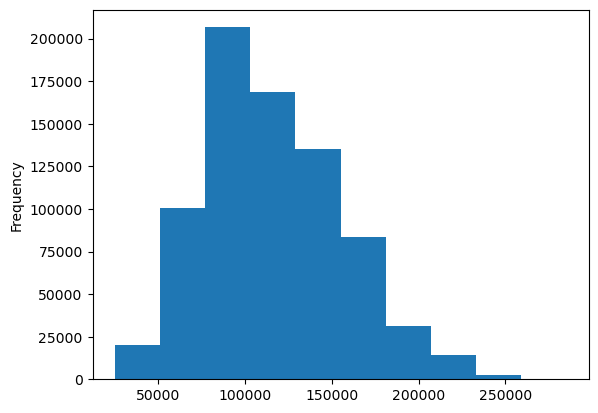

In [6]:
df['salary_year_avg'].plot(kind='hist')

In [7]:
df_da_swe = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Sweden')].copy()

<Axes: ylabel='Frequency'>

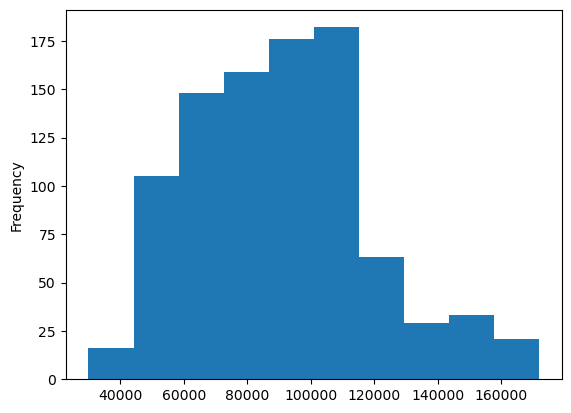

In [10]:
df_da_swe['salary_year_avg'].plot(kind='hist')

In [12]:
df_da_swe_exploded = df_da_swe.explode('job_skills')
df_da_swe_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
432,90000.0,r
432,90000.0,python
432,90000.0,sql
529,140000.0,sql
529,140000.0,sas


In [18]:
df_da_skills = df_da_swe_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)
df_da_skills = df_da_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})
df_da_skills

,skill_count,median_salary
job_skills,,
sql,536,90000.0
python,366,90000.0
tableau,213,90000.0
power bi,203,90000.0
r,186,90000.0
...,...,...
jenkins,1,100000.0
spring,1,81641.0
shell,1,111175.0


In [20]:
df_job_count = len(df_da_swe)

df_da_skills['skill_percent'] = df_da_skills['skill_count'] / df_job_count * 100 

skill_percent = 5

df_da_skills_high_demand = df_da_skills[df_da_skills['skill_percent']> skill_percent]
df_da_skills

,skill_count,median_salary,skill_percent
job_skills,,,
sql,536,90000.0,57.510730
python,366,90000.0,39.270386
tableau,213,90000.0,22.854077
power bi,203,90000.0,21.781116
r,186,90000.0,19.957082
...,...,...,...
jenkins,1,100000.0,0.107296
spring,1,81641.0,0.107296
shell,1,111175.0,0.107296


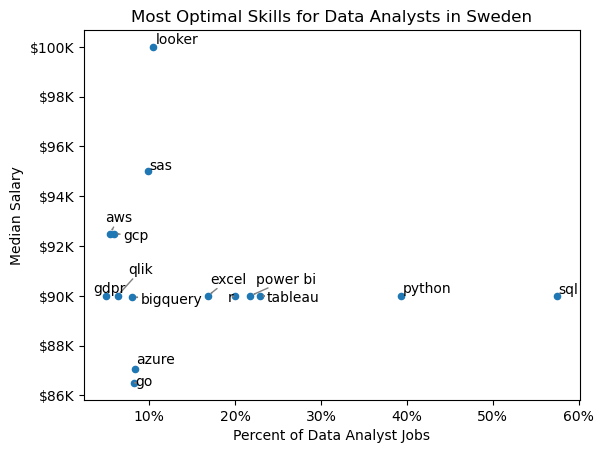

In [29]:
from adjustText import adjust_text

df_da_skills_high_demand.plot(kind='scatter',x='skill_percent', y='median_salary')
text = []
for i, txt in enumerate(df_da_skills_high_demand.index):
    text.append(plt.text(df_da_skills_high_demand['skill_percent'].iloc[i], df_da_skills_high_demand['median_salary'].iloc[i], txt))
    
adjust_text(text, arrowprops=dict(arrowstyle='->', color='gray', lw=1))

plt.title('Most Optimal Skills for Data Analysts in Sweden')
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Salary') 

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
plt.show()


In [31]:


df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing value
            technology_dict[key] += value
        else:                       # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict



{'analyst_tools': ['powerbi',
  'sas',
  'ssrs',
  'powerpoint',
  'esquisse',
  'ssis',
  'spreadsheet',
  'looker',
  'msaccess',
  'outlook',
  'nuix',
  'cognos',
  'qlik',
  'visio',
  'alteryx',
  'splunk',
  'datarobot',
  'sheets',
  'sharepoint',
  'tableau',
  'word',
  'sap',
  'ms access',
  'spss',
  'microstrategy',
  'power bi',
  'dax',
  'excel'],
 'programming': ['css',
  'sql',
  'kotlin',
  'sas',
  'erlang',
  'lua',
  'typescript',
  'c++',
  'golang',
  'ruby',
  'pascal',
  'c#',
  'mongodb',
  'matlab',
  'f#',
  'swift',
  'ocaml',
  'clojure',
  'perl',
  'r',
  'c',
  'java',
  'sass',
  'go',
  'powershell',
  'visual basic',
  'rust',
  'cobol',
  'lisp',
  'groovy',
  'objective-c',
  'php',
  'no-sql',
  'solidity',
  't-sql',
  'delphi',
  'python',
  'html',
  'fortran',
  'elixir',
  'javascript',
  'mongo',
  'assembly',
  'julia',
  'vba',
  'scala',
  'haskell',
  'bash',
  'nosql',
  'visualbasic',
  'apl',
  'crystal',
  'vb.net',
  'shell',
  'd

In [32]:
# turn dictionary into dataframe
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,powerbi
0,analyst_tools,sas
0,analyst_tools,ssrs
0,analyst_tools,powerpoint
0,analyst_tools,esquisse
...,...,...
9,sync,twilio
9,sync,rocketchat
9,sync,mattermost
9,sync,ringcentral


In [37]:
df_plot = df_da_skills_high_demand.merge(df_technology, left_on = 'job_skills', right_on = 'skills')

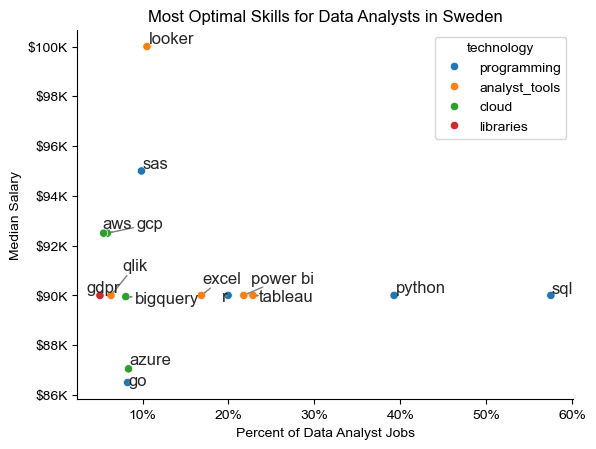

In [40]:
from adjustText import adjust_text

# df_plot.plot(kind='scatter',x='skill_percent', y='median_salary')
sns.scatterplot(
    data = df_plot, 
    x = 'skill_percent',
    y = 'median_salary',
    hue = 'technology'
)

sns.despine()
sns.set_theme(style='ticks')

text = []
for i, txt in enumerate(df_da_skills_high_demand.index):
    text.append(plt.text(df_da_skills_high_demand['skill_percent'].iloc[i], df_da_skills_high_demand['median_salary'].iloc[i], txt))
    
adjust_text(text, arrowprops=dict(arrowstyle='->', color='gray', lw=1))

plt.title('Most Optimal Skills for Data Analysts in Sweden')
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Salary') 

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
plt.show()
